## HBV ensemble analysis

In [1]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Niceties
from rich import print

# General eWaterCycle
import ewatercycle
import ewatercycle.forcing
import ewatercycle.models
from ewatercycle.observation.grdc import get_grdc_data


# ensemble testing hydrostats etc
import hydrostats.metrics as hm
import matplotlib.lines as mlines



In [26]:


ds = get_grdc_data(2617110,
                   '1900-01-01T00:00Z',
                   '2000-12-31T00:00Z',
                   data_home='/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/')

print(f"station = {ds.station_name.values}")

station = KERKI

In [3]:
hbv_dir = Path("../../model_runs/HBV/ensemble_5060")

file_mmd =hbv_dir/ "HBV_Kerki_ensemble_5059_mmd.nc"
file_m3s =hbv_dir / "HBV_Kerki_ensemble_5059_m3s.nc"
file_param = hbv_dir / "HBV_Kerki_ensemble_5059_params.nc"

In [4]:
hbv_mmd = xr.open_dataset(file_mmd, engine="netcdf4")
hbv_m3s = xr.open_dataset(file_m3s, engine="netcdf4")
hbv_params = xr.open_dataset(file_param, engine="netcdf4")

hbv_mmd.close()
hbv_m3s.close()
hbv_params.close()

hbv_mmd_d = hbv_mmd.resample(time="1D").mean()
hbv_m3s_d = hbv_m3s.resample(time="1D").mean()

In [5]:
print(hbv_params)

<xarray.Dataset> Size: 20kB
Dimensions:         (parameter: 9, particle: 250)
Coordinates:
  * parameter       (parameter) <U5 180B 'Imax' 'Ce' 'Sumax' ... 'Kf' 'Ks' 'Fm'
  * particle        (particle) int64 2kB 0 1 2 3 4 5 ... 244 245 246 247 248 249
Data variables:
    hbv_parameters  (particle, parameter) float64 18kB ...

In [6]:
hbv_m3s

<xarray.Dataset> Size: 7MB
Dimensions:    (time: 3652, particle: 250)
Coordinates:
  * time       (time) datetime64[ns] 29kB 1950-01-02T12:00:00 ... 1960-01-01T...
  * particle   (particle) int64 2kB 0 1 2 3 4 5 6 ... 244 245 246 247 248 249
Data variables:
    discharge  (particle, time) float64 7MB ...

In [7]:
hbv_m3s_d


<xarray.Dataset> Size: 7MB
Dimensions:    (time: 3652, particle: 250)
Coordinates:
  * particle   (particle) int64 2kB 0 1 2 3 4 5 6 ... 244 245 246 247 248 249
  * time       (time) datetime64[ns] 29kB 1950-01-02 1950-01-03 ... 1960-01-01
Data variables:
    discharge  (time, particle) float64 7MB 0.5466 5.873 2.191 ... 579.0 420.2

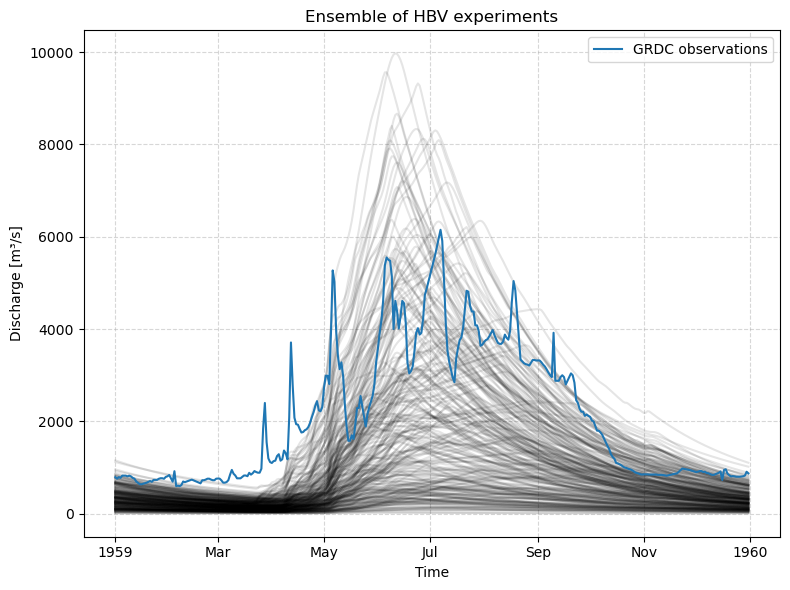

In [8]:


discharge_1955_m3 = hbv_m3s_d.sel(
    time=slice("1959-01-01", "1959-12-31")
)
ds_slice = ds.sel(time=slice("1959-01-01", "1959-12-31"))


plt.figure(figsize=(8,6))

# for i in range(discharge_1955_m3.dims["particle"]):
#     plt.plot(
#         discharge_1955_m3.time,
#         discharge_1955_m3["discharge"].isel(particle=i),
#         alpha=0.2,
#     )

discharge_1955_m3["discharge"].plot(
    x="time",
    hue="particle",
    alpha=0.1,
    add_legend=False,
    color = 'black'
)


ds_slice['streamflow'].plot(label = 'GRDC observations')

plt.xlabel("Time")
plt.ylabel("Discharge [m³/s]")
plt.title("Ensemble of HBV experiments")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
#plt.ylim(0,max_y)
plt.show()

In [9]:
ds

<xarray.Dataset> Size: 316kB
Dimensions:              (time: 19724)
Coordinates:
  * time                 (time) datetime64[ns] 158kB 1936-01-01 ... 1989-12-31
    id                   int64 8B 2617110
Data variables:
    streamflow           (time) float64 158kB 914.0 938.0 926.0 ... 604.0 583.0
    area                 float64 8B 3.09e+05
    country              <U2 8B 'TM'
    geo_x                float64 8B 65.25
    geo_y                float64 8B 37.83
    geo_z                float64 8B 241.0
    owneroforiginaldata  <U85 340B 'Initial dataset collected in the framewor...
    river_name           <U9 36B 'AMU DARYA'
    station_name         <U5 20B 'KERKI'
    timezone             float64 8B nan
Attributes:
    title:          NA
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Converted from 2617110_Q_Day.Cmd.txt of 2025-09-02 to net...
    missing_value:  -999.000

# make table

In [10]:
obs = ds.copy()       
obs["discharge"] = ds["streamflow"]

hbv_aligned, obs_aligned = xr.align(
    hbv_m3s_d,
    obs,
    join="inner"   # intersection of time indices
)

hbv_da = hbv_aligned["discharge"]
obs_da = obs_aligned["discharge"]


aligned_ds = xr.Dataset(
    {
        "hbv": hbv_da,
        "obs": obs_da,
    }
)

aligned_clean = aligned_ds.dropna(dim="time", how="any")

In [11]:
# Copy original obs dataset
obs_shifted = obs.copy()

# Shift time by 25 days
time_offset = pd.Timedelta(days=25)
obs_shifted = obs_shifted.assign_coords(time=obs_shifted.time + time_offset)

# Align with hbv_m3s_d again (intersection of new time indices)
hbv_aligned_shifted, obs_aligned_shifted = xr.align(
    hbv_m3s_d,
    obs_shifted,
    join="inner"  # only keep times present in both
)

# Create new aligned dataset
aligned_ds_shifted = xr.Dataset(
    {
        "hbv": hbv_aligned_shifted["discharge"],
        "obs_shifted": obs_aligned_shifted["discharge"],
    }
)

# Drop any NaNs if necessary
aligned_clean_shifted = aligned_ds_shifted.dropna(dim="time", how="any")

aligned_clean_shifted

<xarray.Dataset> Size: 5MB
Dimensions:      (particle: 250, time: 2331)
Coordinates:
  * particle     (particle) int64 2kB 0 1 2 3 4 5 6 ... 244 245 246 247 248 249
  * time         (time) datetime64[ns] 19kB 1952-07-08 1952-07-09 ... 1960-01-01
    id           int64 8B 2617110
Data variables:
    hbv          (time, particle) float64 5MB 305.2 670.7 ... 579.0 420.2
    obs_shifted  (time) float64 19kB 3.63e+03 3.79e+03 3.89e+03 ... 911.0 884.0

In [12]:
# --- Select years ---
start_year = 1950
end_year = 1959

aligned_sel = aligned_clean_shifted.sel(
    time=slice(f"{start_year}-01-01", f"{end_year}-12-31")
)

In [13]:
print(aligned_sel)

<xarray.Dataset> Size: 5MB
Dimensions:      (particle: 250, time: 2330)
Coordinates:
  * particle     (particle) int64 2kB 0 1 2 3 4 5 6 ... 244 245 246 247 248 249
  * time         (time) datetime64[ns] 19kB 1952-07-08 1952-07-09 ... 1959-12-31
    id           int64 8B 2617110
Data variables:
    hbv          (time, particle) float64 5MB 305.2 670.7 ... 585.9 424.4
    obs_shifted  (time) float64 19kB 3.63e+03 3.79e+03 3.89e+03 ... 904.0 911.0

In [14]:
metric = hm.ve

performance = xr.apply_ufunc(
    metric,
    aligned_sel["hbv"],
    aligned_sel["obs_shifted"],
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[[]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
)
performance = performance.reset_coords("id", drop=True)

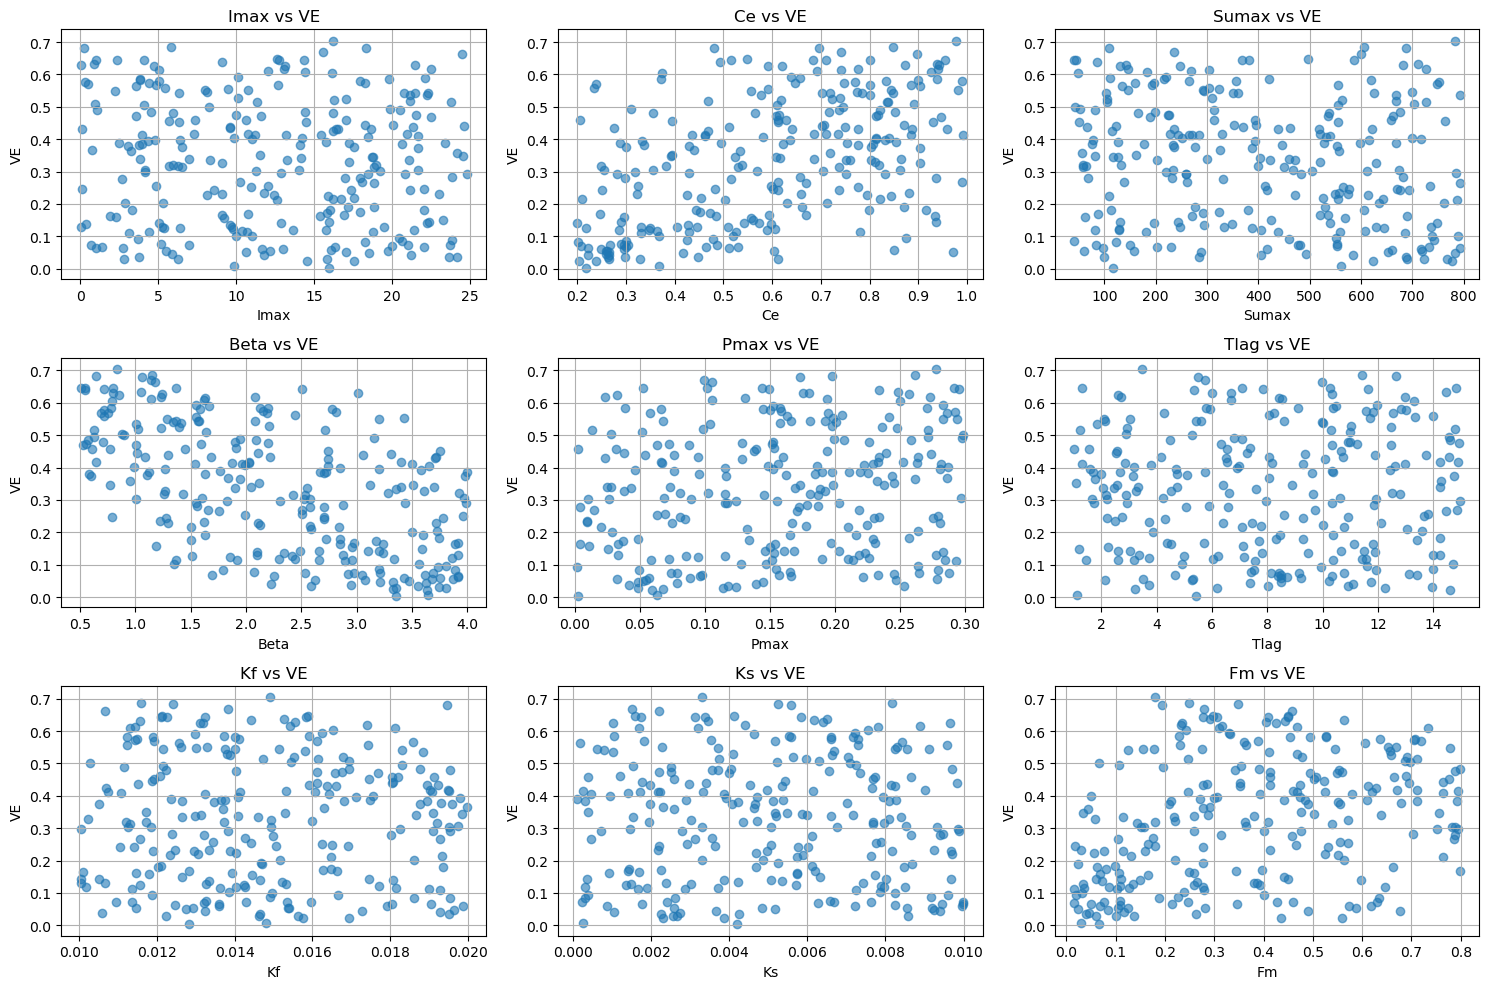

In [15]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

param_names = hbv_params.parameter.values
performance.name = metric.abbr  # or KGE etc.

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, pname in enumerate(param_names):
    param = hbv_params["hbv_parameters"].sel(parameter=pname)
    axes[i].scatter(param, performance, alpha=0.6)
    axes[i].set_xlabel(pname)
    axes[i].set_ylabel(performance.name)
    axes[i].set_title(f"{pname} vs {performance.name}")
    axes[i].grid(True)

for ax in axes[len(param_names):]:
    fig.delaxes(ax)  # remove extra axes

plt.tight_layout()
plt.show()


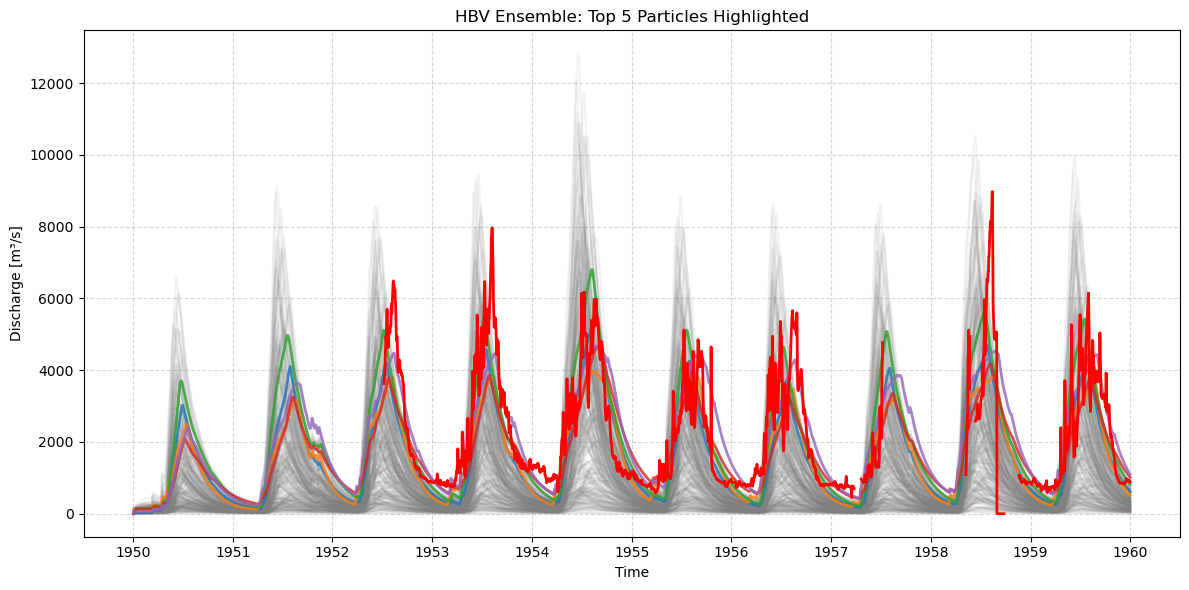

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# n_top = 5

# # Performance array (1D numpy)
# perf_vals = performance

# # Get top N particle **positions**
# top_positions = np.argsort(perf_vals)[-n_top:]

# # Extract hbv as NumPy arrays
hbv_all_vals = aligned_ds_shifted["hbv"].values  # shape (time, particle)
time_vals = aligned_ds_shifted["hbv"].time.values
obs_vals = aligned_ds_shifted["obs_shifted"].values

n_top = 5
top_positions = np.argsort(performance.values)[-n_top:]  # numpy argsort
top_particles = performance.particle[top_positions]      # coordinate labels

# Select top HBV particles
hbv_top = aligned_ds["hbv"].sel(particle=top_particles)

# Plot
plt.figure(figsize=(12,6))

# All particles faintly
for i in range(hbv_all_vals.shape[1]):
    plt.plot(time_vals, hbv_all_vals[:, i], color="gray", alpha=0.1)

# Top performers
for i in top_positions:
    plt.plot(time_vals, hbv_all_vals[:, i], linewidth=2, alpha=0.8, label=f"Particle {i}")

# Observations
plt.plot(time_vals, obs_vals, color="red", linewidth=2, label="Obs")

plt.xlabel("Time")
plt.ylabel("Discharge [m³/s]")
plt.title(f"HBV Ensemble: Top {n_top} Particles Highlighted")
plt.grid(True, linestyle="--", alpha=0.5)
#plt.legend()
plt.tight_layout()
plt.show()


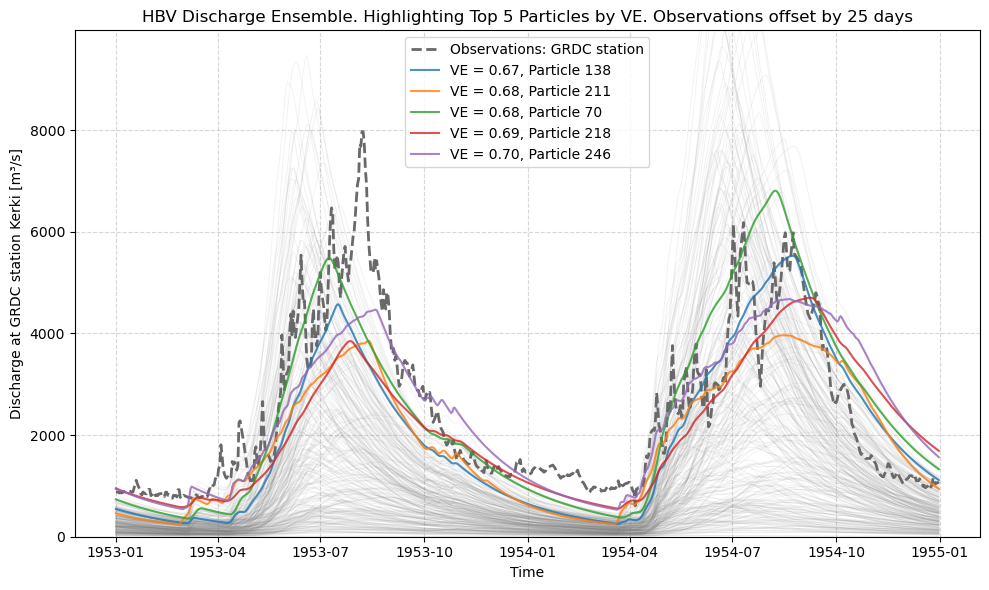

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- Select years ---
start_year = 1953
end_year = 1954

# Convert to boolean mask
time_mask = (time_vals >= np.datetime64(f"{start_year}-01-01")) & \
            (time_vals <= np.datetime64(f"{end_year}-12-31"))



# Apply mask to time and data
time_sel = time_vals[time_mask]
hbv_all_sel = hbv_all_vals[time_mask, :]
obs_sel = obs_vals[time_mask]

# --- Plot ---
plt.figure(figsize=(10,6 ))

# All particles faintly
# for i in range(hbv_all_sel.shape[1]):
#     plt.plot(time_sel, hbv_all_sel[:, i], color="gray", alpha=0.1)
for i in range(hbv_all_sel.shape[1]):
    plt.plot(time_sel, hbv_all_sel[:, i], color="gray", alpha=0.1, linewidth=0.7)


# --- Plot observations ---
plt.plot(
    time_sel,
    obs_sel,
    color="dimgray",  # dark grey
    linewidth=2,
    linestyle="--",
    label="Observations: GRDC station"
)



# Add empty line in legend
empty_line = mlines.Line2D([], [], linestyle='None', label=' ')


# top particles with corrected label
for i in top_positions:
    plt.plot(
        time_sel,
        hbv_all_sel[:, i],
        linewidth=1.5,
        alpha=0.8,
        label=f"{metric.abbr} = {performance[i].item():3.2f}, Particle {i}"
    )





plt.xlabel("Time")
plt.ylabel("Discharge at GRDC station Kerki [m³/s]")
plt.title(f"HBV Discharge Ensemble. Highlighting Top {n_top} Particles by {metric.abbr}. Observations offset by 25 days") #. Highlighted ({start_year}-{end_year})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.ylim(0, 1.25*np.max(obs_sel))
plt.legend()
plt.tight_layout()
plt.show()


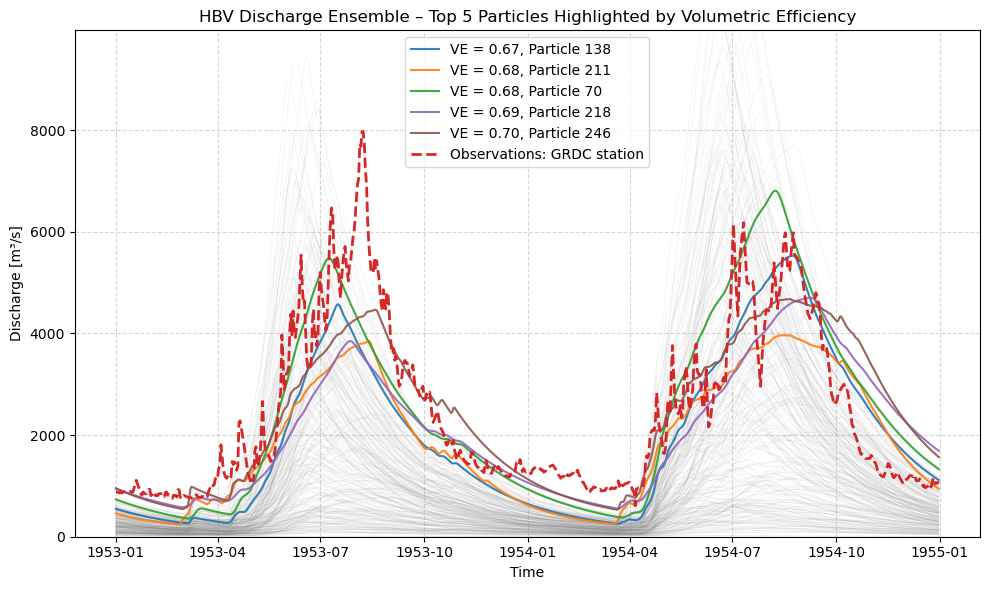

In [18]:
plt.figure(figsize=(10,6))

# --- Plot all ensemble particles faintly ---
for i in range(hbv_all_sel.shape[1]):
    plt.plot(time_sel, hbv_all_sel[:, i], color="gray", alpha=0.1, linewidth=0.5)

# --- Plot top particles ---
top_colors = ["tab:blue", "tab:orange", "tab:green", "tab:purple", "tab:brown"]  # cycle if n_top > 5
for idx, i in enumerate(top_positions):
    plt.plot(
        time_sel,
        hbv_all_sel[:, i],
        color=top_colors[idx % len(top_colors)],
        linewidth=1.5,
        alpha=0.9,
        label=f"{metric.abbr} = {performance[i].item():.2f}, Particle {i}"
    )

# --- Plot observations ---
plt.plot(
    time_sel,
    obs_sel,
    color="tab:red",
    linewidth=2,
    linestyle="--",
    label="Observations: GRDC station"
)

plt.xlabel("Time")
plt.ylabel("Discharge [m³/s]")
plt.title(f"HBV Discharge Ensemble – Top {n_top} Particles Highlighted by {metric.name}")
plt.grid(True, linestyle="--", alpha=0.5)
plt.ylim(0, 1.25*np.max(obs_sel))
plt.legend()
plt.tight_layout()
plt.show()